# Single-influx random communities (`JansSampler3`)

Reproduces `notebooks/forfigures/Single influx.ipynb`. We sample random multi-strain / multi-resource communities with a single influx resource, find the non-spatial steady state of each, and classify it via the linear-stability scan. The goal is the qualitative split of communities into **extinct / stable / Turing-unstable** as $K$ is varied.

In [1]:
import sys, pathlib
_root = pathlib.Path.cwd().parent
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_context("talk", rc={"font.size": 15, "axes.titlesize": 15, "axes.labelsize": 15})
sns.set_style("whitegrid", {"grid.color": '.9', 'grid.linestyle': '--', 'axes.edgecolor': '.6', 'xtick.bottom': True, 'ytick.left': True})

from ssmc.sampling import JansSampler3, Dirac
from ssmc.linstab import scan_k, classify
from ssmc.solver import solve_steady_state
from ssmc.plotting import STATE_COLORS, plot_dispersion

In [10]:
def make_sampler(K, l_influx, Ns=30, Nr=30, num_byproducts=2, D=1.0):
    """Single-influx sampler with equal resource diffusion (`Dr = Drinflux = D`).

    Turing instability still arises when leakage is high enough (`l > 0.5`) and
    `K` crosses the instability line `K = m·r / (c·(1 - l))`. Unequal diffusion
    would increase the fraction of unstable draws but is not required.
    """
    return JansSampler3(
        Ns=Ns,
        Nr=Nr,
        m=stats.lognorm(s=0.3, scale=1.0),
        r=Dirac(1.0),
        num_influx_resources=1,
        K=Dirac(K),
        prob_eating=0.7,
        prob_eating_influx=1.0,
        num_byproducts=Dirac(num_byproducts),
        c=stats.lognorm(s=0.3, scale=1.0),
        l=stats.uniform(loc=0.6, scale=0.35),
        cinflux=stats.lognorm(s=0.3, scale=1.0),
        linflux=Dirac(l_influx),
        Ds=Dirac(1e-12),
        Dr=Dirac(D),
        Drinflux=Dirac(D),
    )

In [11]:
def classify_one(sparams, ks=None, t_max=2e3):
    if ks is None:
        ks = np.logspace(-3, 2.5, 1000)
    micrm = sparams.micrm
    Ns, Nr = micrm.Ns, micrm.Nr
    u0 = np.concatenate([0.1 * np.ones(Ns), micrm.K / np.maximum(micrm.r, 1e-6)])
    u_ss, ok = solve_steady_state(micrm, u0, t_max=t_max, rtol=1e-7, atol=1e-9)
    if not ok:
        return 'extinct'
    if np.max(u_ss[:Ns]) < 1e-6:
        return 'extinct'
    res = scan_k(sparams, u_ss, ks)
    return classify(res)

In [16]:
from scipy import stats as scistats

def wilson_ci(k, n, alpha=0.05):
    """Wilson score interval for a binomial proportion — same as Julia's BinomialTest confint(:wilson)."""
    if n == 0:
        return (0.0, 0.0)
    z = scistats.norm.isf(alpha / 2)
    phat = k / n
    denom = 1 + z * z / n
    centre = (phat + z * z / (2 * n)) / denom
    half = (z / denom) * np.sqrt(phat * (1 - phat) / n + z * z / (4 * n * n))
    return (max(0.0, centre - half), min(1.0, centre + half))

Ks = np.geomspace(0.3, 1e3, 7)
n_per_cell = 10
l_influx_vals = [1.0]

rng = np.random.default_rng(42)

counts = {l: {s: np.zeros(len(Ks), dtype=int) for s in ('extinct', 'stable', 'unstable')} for l in l_influx_vals}

for l_inf in l_influx_vals:
    for j, K in enumerate(Ks):
        sampler = make_sampler(K=float(K), l_influx=l_inf)
        for _ in range(n_per_cell):
            sparams = sampler(rng)
            label = classify_one(sparams)
            if label in counts[l_inf]:
                counts[l_inf][label][j] += 1

In [8]:
l_inf

0.98

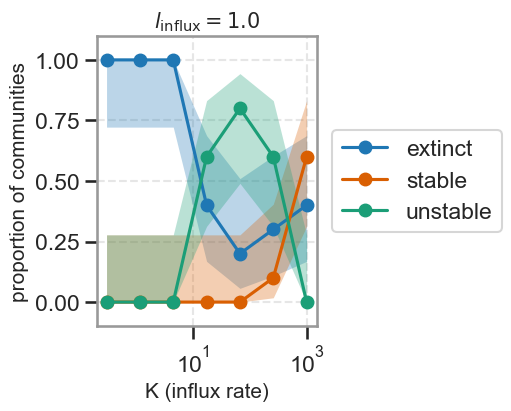

In [17]:
fig, axes = plt.subplots(1, len(l_influx_vals), figsize=(5 * len(l_influx_vals), 4), sharey=True, constrained_layout=True)

if len(l_influx_vals) == 1:
    axes = [axes]

for ax, l_inf in zip(axes, l_influx_vals):
    for state in ('extinct', 'stable', 'unstable'):
        n_state = counts[l_inf][state]
        p = n_state / n_per_cell
        lo = np.empty_like(p); hi = np.empty_like(p)
        for j in range(len(Ks)):
            lo[j], hi[j] = wilson_ci(int(n_state[j]), n_per_cell)
        ax.plot(Ks, p, marker='o', color=STATE_COLORS[state], label=state)
        ax.fill_between(Ks, lo, hi, color=STATE_COLORS[state], alpha=0.3, linewidth=0)
    ax.set_xscale('log')
    ax.set_xlabel('K (influx rate)')
    ax.set_title(f"$l_{{\\rm influx}} = {l_inf}$")
    ax.set_ylim(-0.1, 1.1)
axes[0].set_ylabel('proportion of communities')
axes[-1].legend(loc='center left', bbox_to_anchor=(1.02, 0.5))
plt.show()

## Example dispersion relation

Pick one community drawn at high $K, l_{\rm influx}$ and plot its dispersion relation.

In [15]:
rng2 = np.random.default_rng(7)
sampler = make_sampler(K=30.0, l_influx=0.95)
for _ in range(20):
    sparams = sampler(rng2)
    micrm = sparams.micrm
    Ns = micrm.Ns
    u0 = np.concatenate([0.1 * np.ones(Ns), micrm.K / np.maximum(micrm.r, 1e-6)])
    u_ss, ok = solve_steady_state(micrm, u0, t_max=2e3)
    if not ok or np.max(u_ss[:Ns]) < 1e-6:
        continue
    ks = np.linspace(1e-3, 200.0, 2000)
    res = scan_k(sparams, u_ss, ks)
    if classify(res) == 'unstable':
        break

fig, ax = plt.subplots(figsize=(7, 4))
plot_dispersion(ax, res.ks, res.mrls)
ax.set_title(f"dispersion (code={res.code}) — peak at k={res.max_k:.2f}")
ax.legend()
plt.show()

KeyboardInterrupt: 